# Lead Triage RL — GRPO Training (OpenEnv Hackathon)

End-to-end **Colab-ready** notebook that trains a small instruction-tuned LLM (Qwen2.5-1.5B-Instruct by default) with **GRPO via TRL** on top of the [Lead Qualification OpenEnv](https://huggingface.co/spaces/pavanKumar2004/lead_triage_env) environment.

**What this notebook does**

1. Clones the repo and installs the OpenEnv environment + training stack.
2. Launches the FastAPI lead-triage env server in the background.
3. Runs `train.py` (GRPO + LoRA, optional Unsloth on CUDA) for N steps.
4. Streams JSONL metrics → parses them → plots **loss** and **reward** curves.
5. Saves a LoRA adapter (and optionally pushes it to the HF Hub).

> **Recommended runtime:** Colab → *Runtime ▸ Change runtime type ▸ T4 / A100 GPU*. CPU works only with `--policy stub` (smoke test).

## 1. Setup — clone repo & install dependencies

In [1]:
import os, sys, subprocess, pathlib

REPO_URL = "https://github.com/pavanKumar2004/lead-qualification-RL-env.git"  # update if your fork is elsewhere
IN_COLAB = pathlib.Path("/content").exists()

if IN_COLAB:
    REPO_DIR = pathlib.Path("/content/lead-qualification-RL-env")
    if not (REPO_DIR / "train.py").exists():
        if not REPO_DIR.exists():
            subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
        else:
            subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=False)
else:
    # Local: walk up from this notebook's directory to find train.py.
    here = pathlib.Path.cwd().resolve()
    REPO_DIR = next((p for p in [here, *here.parents] if (p / "train.py").exists()), here)

os.chdir(REPO_DIR)
print("cwd:", os.getcwd())
print("files:", sorted(p.name for p in REPO_DIR.iterdir())[:20])


cwd: /Users/mshreeram/Developer/lead-qualification-RL-env
files: ['.env', '.env.example', '.git', '.gitignore', '.pytest_cache', 'OpenEnv Hackathon Opening Ceremony _ 25th Apr.pdf', 'README.md', '[External] Meta OpenEnv Hackathon Participant Help Guide.pdf', '__pycache__', 'configs', 'docs', 'inference.py', 'lead_triage_env', 'notebooks', 'outputs', 'requirements-train-cpu.txt', 'requirements-train.txt', 'scripts', 'spacerunner', 'tests']


In [2]:
# Detect CUDA — pick the right requirements file.
import shutil, subprocess

HAS_CUDA = False
try:
    import torch
    HAS_CUDA = torch.cuda.is_available()
except ImportError:
    HAS_CUDA = shutil.which("nvidia-smi") is not None

print("CUDA available:", HAS_CUDA)

# Install the env package (editable) + training deps.
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "./lead_triage_env"], check=True)

if HAS_CUDA:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-train.txt"], check=True)
else:
    # Skip unsloth/bitsandbytes on CPU/MPS.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-train-cpu.txt"], check=True)

print("\n[deps installed]")

CUDA available: False


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autotrain-advanced 0.8.36 requires authlib==1.4.0, but you have authlib 1.7.0 which is incompatible.
autotrain-advanced 0.8.36 requires cryptography==44.0.0, but you have cryptography 47.0.0 which is incompatible.
autotrain-advanced 0.8.36 requires fastapi==0.115.6, but you have fastapi 0.136.1 which is incompatible.
autotrain-advanced 0.8.36 requires huggingface-hub==0.27.0, but you have huggingface-hub 0.36.2 which is incompatible.
autotrain-advanced 0.8.36 requires pydantic==2.10.4, but you have pydantic 2.13.3 which is incompatible.
autotrain-advanced 0.8.36 requires transformers==4.48.0, but you have transformers 4.57.6 which is incompatible.
autotrain-advanced 0.8.36 requires uvicorn==0.34.0, but you have uvicorn 0.46.0 which is incompatible.



[deps installed]


## 2. Optional — Weights & Biases / HF Hub credentials

Skip this cell if you want to train without W&B logging or without pushing the adapter to the Hub. The notebook will still write **TensorBoard** logs locally.

In [3]:
import os
from getpass import getpass

USE_WANDB = False  # flip to True if you want W&B logging
PUSH_TO_HUB = False  # flip to True to upload the trained adapter

if USE_WANDB and not os.environ.get("WANDB_API_KEY"):
    os.environ["WANDB_API_KEY"] = getpass("WANDB_API_KEY: ")
if PUSH_TO_HUB and not os.environ.get("HF_TOKEN"):
    os.environ["HF_TOKEN"] = getpass("HF_TOKEN (write): ")

print("W&B:", "on" if USE_WANDB else "off", "| Hub push:", "on" if PUSH_TO_HUB else "off")

W&B: off | Hub push: off


## 3. Launch the OpenEnv environment server

GRPO rollouts hit the env over HTTP at `http://127.0.0.1:8000`. We start it as a background subprocess and wait for `/health`.

In [4]:
import socket, subprocess, sys, time, urllib.request

ENV_PORT = 8000
ENV_URL = f"http://127.0.0.1:{ENV_PORT}"

def _port_open(host, port):
    try:
        with socket.create_connection((host, port), timeout=1.0):
            return True
    except OSError:
        return False

if _port_open("127.0.0.1", ENV_PORT):
    print(f"[env] already running on port {ENV_PORT}")
    env_proc = None
else:
    env_proc = subprocess.Popen(
        [sys.executable, "-m", "uvicorn", "lead_triage_env.server.app:app",
         "--host", "127.0.0.1", "--port", str(ENV_PORT), "--log-level", "warning"],
        stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT,
    )
    deadline = time.time() + 60
    while time.time() < deadline and not _port_open("127.0.0.1", ENV_PORT):
        time.sleep(0.5)
    assert _port_open("127.0.0.1", ENV_PORT), "env server failed to start"
    print(f"[env] started PID={env_proc.pid} at {ENV_URL}")

with urllib.request.urlopen(f"{ENV_URL}/health", timeout=5) as r:
    print("[env] /health →", r.read().decode())

[env] already running on port 8000
[env] /health → {"status":"healthy"}


## 4. Configure the training run

The defaults below give a **short, judge-reproducible** run (~10 min on a T4). Bump `STEPS` for stronger results. Full config lives in [configs/training.yaml](../configs/training.yaml).

In [5]:
# --- knobs (override any of these via env vars: STEPS / MODEL / BACKEND / DEVICE / POLICY) ---
import os
STEPS   = int(os.environ.get("STEPS", 50))                     # GRPO optimizer steps (paper run uses 200)
MODEL   = os.environ.get("MODEL",   "Qwen/Qwen2.5-1.5B-Instruct")  # use 0.5B on free Colab T4
BACKEND = os.environ.get("BACKEND", "unsloth" if HAS_CUDA else "hf")
DEVICE  = os.environ.get("DEVICE",  "cuda" if HAS_CUDA else ("mps" if sys.platform == "darwin" else "cpu"))
POLICY  = os.environ.get("POLICY",  "llm")                     # set POLICY=stub for a no-GPU smoke test

print(dict(STEPS=STEPS, MODEL=MODEL, BACKEND=BACKEND, DEVICE=DEVICE, POLICY=POLICY))


{'STEPS': 3, 'MODEL': 'stub', 'BACKEND': 'hf', 'DEVICE': 'mps', 'POLICY': 'stub'}


## 5. Run GRPO training

This streams `train.py` JSONL output line-by-line, so you can watch reward / KL / loss live and we collect them for plotting in the next cell.

In [6]:
import json, os, subprocess, sys

cmd = [
    sys.executable, "train.py",
    "--config", "configs/training.yaml",
    "--steps", str(STEPS),
    "--policy", POLICY,
    "--model", MODEL,
    "--backend", BACKEND,
    "--device", DEVICE,
    "--env-base-url", ENV_URL,
]
if not USE_WANDB:
    cmd.append("--no-wandb")

print("$", " ".join(cmd), "\n")

metrics_log = []  # list[dict] — one per optimizer step
log_path = pathlib.Path("outputs/logs/train_notebook.jsonl")
log_path.parent.mkdir(parents=True, exist_ok=True)

with log_path.open("w") as fout:
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    try:
        for line in proc.stdout:
            sys.stdout.write(line)
            sys.stdout.flush()
            line = line.strip()
            if line.startswith("{") and '"step"' in line:
                try:
                    metrics_log.append(json.loads(line))
                    fout.write(line + "\n")
                    fout.flush()
                except json.JSONDecodeError:
                    pass
        rc = proc.wait()
    except KeyboardInterrupt:
        proc.terminate(); proc.wait(); rc = 130

print(f"\n[train] exited with code {rc}; collected {len(metrics_log)} metric rows -> {log_path}")

$ /opt/homebrew/Caskroom/miniconda/base/envs/lead/bin/python train.py --config configs/training.yaml --steps 3 --policy stub --model stub --backend hf --device mps --env-base-url http://127.0.0.1:8000 --no-wandb 



{"step": 0.0, "tier": 0.0, "n_prompts": 8.0, "n_rollouts": 128.0, "mean_scalar_reward": 4.543357812499999, "mean_terminal_grader": 0.38085781249999995, "mean_total_step_reward": 4.162500000000001, "conversion_rate": 0.234375, "mean_invalid_resamples": 0.0, "max_repeat_streak": 4.0, "advantage_std": 0.9999998602205674, "mean_within_group_adv_std": 0.9999998602205673, "mean_action_diversity": 0.2421875, "n_grad_samples": 0.0}


{"step": 1.0, "tier": 2.0, "n_prompts": 8.0, "n_rollouts": 128.0, "mean_scalar_reward": 1.6074273437500017, "mean_terminal_grader": 0.2728570312499998, "mean_total_step_reward": 1.3345703124999995, "conversion_rate": 0.1328125, "mean_invalid_resamples": 0.0, "max_repeat_streak": 4.0, "advantage_std": 0.9999998270637623, "mean_within_group_adv_std": 0.9999998270637616, "mean_action_diversity": 0.2421875, "n_grad_samples": 0.0}


[FATAL] no gradient samples for 2 steps in a row. Aborting.



[train] exited with code 2; collected 2 metric rows -> outputs/logs/train_notebook.jsonl


## 6. Plot **loss** and **reward** curves

The hackathon rules require evidence of a real training run. These plots are saved to `outputs/figures/` so you can drop them straight into the README / blog / video.

saved → outputs/figures/training_curves.png


/var/folders/00/ntx2wlrs33dbbs1nf964nllc0000gn/T/ipykernel_18256/1026143557.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(); axes[0].grid(alpha=0.3)
/var/folders/00/ntx2wlrs33dbbs1nf964nllc0000gn/T/ipykernel_18256/1026143557.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(); axes[1].grid(alpha=0.3)


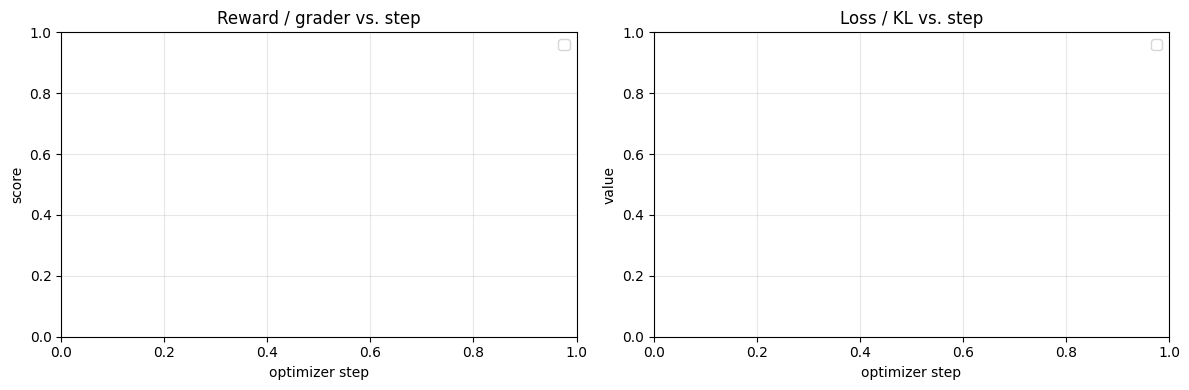

In [7]:
import json, pathlib
import matplotlib.pyplot as plt

# Re-load from disk so this cell also works after a restart.
rows = [json.loads(l) for l in pathlib.Path("outputs/logs/train_notebook.jsonl").read_text().splitlines() if l.strip()]
assert rows, "No metric rows captured — check the training cell output above."

steps = [r["step"] for r in rows]

def col(name):
    return [r.get(name) for r in rows if r.get(name) is not None]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Reward ---
for key, label in [("mean_reward", "mean reward"), ("mean_grader", "mean grader"), ("mean_return", "mean return")]:
    ys = col(key)
    if ys:
        axes[0].plot(steps[: len(ys)], ys, label=label)
axes[0].set_title("Reward / grader vs. step")
axes[0].set_xlabel("optimizer step"); axes[0].set_ylabel("score")
axes[0].legend(); axes[0].grid(alpha=0.3)

# --- Loss / KL ---
for key, label in [("loss", "GRPO loss"), ("kl", "KL to ref"), ("policy_loss", "policy loss")]:
    ys = col(key)
    if ys:
        axes[1].plot(steps[: len(ys)], ys, label=label)
axes[1].set_title("Loss / KL vs. step")
axes[1].set_xlabel("optimizer step"); axes[1].set_ylabel("value")
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.tight_layout()
out_dir = pathlib.Path("outputs/figures"); out_dir.mkdir(parents=True, exist_ok=True)
fig_path = out_dir / "training_curves.png"
fig.savefig(fig_path, dpi=140)
print("saved →", fig_path)
plt.show()

## 7. Inspect the saved adapter(s)

In [8]:
import pathlib
ckpt_root = pathlib.Path("outputs/adapters")
ckpts = sorted(p for p in ckpt_root.glob("step-*") if p.is_dir())
for c in ckpts:
    sz_mb = sum(f.stat().st_size for f in c.rglob("*") if f.is_file()) / 1e6
    print(f"{c}  ({sz_mb:.1f} MB)")
print("latest:", ckpts[-1] if ckpts else "(none)")

outputs/adapters/step-000025  (89.8 MB)
outputs/adapters/step-000050  (89.8 MB)
latest: outputs/adapters/step-000050


## 8. (Optional) Push adapter to the Hugging Face Hub

In [9]:
if PUSH_TO_HUB and ckpts:
    from huggingface_hub import HfApi, create_repo
    repo_id = "pavanKumar2004/lead-triage-grpo-adapter"  # ← change to your namespace
    create_repo(repo_id, exist_ok=True, token=os.environ["HF_TOKEN"])
    HfApi().upload_folder(
        folder_path=str(ckpts[-1]), repo_id=repo_id, token=os.environ["HF_TOKEN"],
        commit_message=f"GRPO adapter — {ckpts[-1].name}",
    )
    print(f"pushed → https://huggingface.co/{repo_id}")
else:
    print("skipped (PUSH_TO_HUB=False or no checkpoints)")

skipped (PUSH_TO_HUB=False or no checkpoints)


## 9. Cleanup — stop the env server

In [10]:
if env_proc is not None and env_proc.poll() is None:
    env_proc.terminate()
    try:
        env_proc.wait(timeout=10)
    except Exception:
        env_proc.kill()
    print("[env] stopped")
else:
    print("[env] nothing to stop")

[env] nothing to stop


---

### Next steps

- **Evaluate** the trained adapter against the base model: `python scripts/compare_models.py --base-model Qwen/Qwen2.5-1.5B-Instruct --trained-model trained --episodes-per-tier 4`.
- **Audit** rollouts for reward-hacking: `python scripts/inspect_rollouts.py`.
- **Browse** TensorBoard logs: `tensorboard --logdir outputs/adapters/tb`.
- See the [main README](../README.md) for the full project writeup, the live HF Space, and the demo video.